In [1]:
#VaR tests and vizualization
from scipy.stats import *
from scipy import stats 
from typing import Union, List, Literal, TypeAlias
import numpy as np
import numpy.typing as npt
import pandas as pdФ
from functools import wraps, partial
from arch import arch_model
import matplotlib.pyplot as plt

from Vares_simulations import *

from Vares import _terminal_returns, historical_var

Vares.ENABLE_TIMING = False

import pickle

#import the USD data 
with open('prices_usd.pkl', 'rb') as f: 
    prices_usd = pickle.load(f)

with open('original_returns_usd.pkl', 'rb') as f: 
    original_returns_usd = pickle.load(f)

with open('log_returns_usd.pkl', 'rb') as f: 
    log_returns_usd = pickle.load(f)    

original_returns_usd_scaled = original_returns_usd * 100
log_returns_usd_scaled = log_returns_usd * 100

from GARCH_VaR_delete_or_merge import fit_GARCH_VaR

import pickle

with open("norm_vars.pkl", "rb") as f:
    _norm_vars = pickle.load(f)

def turn_var_into_real_terms(var_array, prices):
    return [np.exp(log_delta) * price for log_delta, price in zip(var_array, prices)]

In [ ]:
#make_random_path_simulator_local_vol_mean_student
def simulation(
    params: SimParams,
    T: int, 
    nu: float, 
    dist = 't',
    granularity: int = 1000,
):
    '''Simulates returns driven by the Student innovation. Allows for dynamic mean. 
    Returns a batch of simulated data. The simulated data is logged.  Works with the log returns best'''
    if params.volatility.shape[0] != params.mean.shape[0]:
        raise ValueError('params.volatility.shape[0] has to be equal to params.mean.shape[0]')

    if T < params.volatility.shape[0]: 
        raise ValueError('Quantity of forecasted volatility can not exceed number of days to simulte')
    
    elif T > params.volatility.shape[0]:
        print('Number of simulated days exceed number of forecasted volality points. Simulation will assume constant long-term volatility.')

    def simulate(n_paths: int, seed = None):
        if seed is not None:
            rng = np.random.default_rng(seed=seed)
        else:
            rng = np.random.default_rng()

        time_grid = T * granularity
        dt = 1 / granularity
        Z = stats.t.rvs(df=nu, size=(n_paths, time_grid)) #the innovation random variabled
        if nu > 2.0: 
            stoch_comp = Z * np.sqrt(nu-2) / np.sqrt(nu) #scaled to have unit variance 
        else: 
            raise ValueError('Can not model the price process as the innovation variable has non-finite variance')

        #iterating through available volatility points 
        d_log_S = np.zeros(shape=(n_paths, time_grid))
        for t in range(params.volatility.shape[0]):
            _t = t * granularity
            d_log_S[:, _t:_t+granularity] = (
                params.mean[t] * dt + 
                params.volatility[t] * stoch_comp[:, _t:_t+granularity] * np.sqrt(t)
            )
        _T = params.volatility.shape[0] * granularity
        d_log_S[:, _T:] = ((params.mean[-1] * dt) +
                    + params.volatility[-1] * stoch_comp[:, _T:] * np.sqrt(dt))

        cum_log_returns = np.cumsum(d_log_S, axis=-1)
        return cum_log_returns
 
    return simulate

In [3]:
nu = 4 #degrees of freedom
Z = stats.t.rvs(df=nu, size=1000)
stoch_comp = Z * np.sqrt(nu-2) / np.sqrt(nu)

print(np.std(Z), np.var(Z))
print(np.std(stoch_comp), np.var(stoch_comp))


1.4606504558666147 2.133499754223349
1.0328358422865052 1.0667498771116746


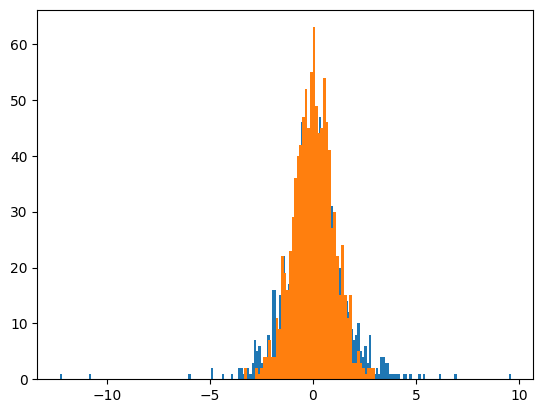

In [239]:
Q = stats.norm.rvs(size=1000)
plt.hist(Z, bins=200)
plt.hist(Q, bins=50)
plt.show()

In [231]:
nu = 4 #degrees of freedom
_std = stats.t(nu).std()
Z = stats.t.rvs(df=nu, size=1000, scale=(1/_std))


print(np.std(Z), np.var(Z))
print('--------------------------------')

variance = 1.5 ** 2
std = variance ** (1/2)

Z = stats.t.rvs(df=nu, size=1000, scale=(std / _std))
print(np.std(Z))

# stoch_comp = Z * std
# print(np.std(stoch_comp))

1.0162007232270942 1.0326639098872692
--------------------------------
1.5302901094815389


In [5]:

array1 = []
for _ in range(50000): 
    Z = stats.t.rvs(df=nu, size=1000)
    stoch_comp = Z * np.sqrt(nu-2) / np.sqrt(nu)
    array1.append(np.std(stoch_comp))

print(np.mean(array1), np.std(array1))
print('-------------')


array2 = []
for _ in range(50000): 
    Z = stats.t.rvs(df=nu, size=1000, scale=(1/_std))
    array2.append(np.std(Z))

print(np.mean(array2), np.std(array2))

0.9976125098849139 0.06366614458130762
-------------
0.997783937653641 0.06670530086858041


    COMPARISON OF THE NORMAL DRIVEN GARCH AND STUDENT DRIVEN ONE 

In [271]:
def student_simulation(returns, horizon=10, n_paths=50_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='GARCH', p=1, o=0, q=1, dist='t', rescale=False)
    results = model.fit(disp='off')
    forecast = results.forecast(horizon=horizon)
    # mu = results.params.get("mu", 0)
    mu = forecast.mean.values[0]
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu) #FITS VARIANCE INSTEAD OF STANDARD DEVIATION
    
    return parameters, nu 

def normal_simulation(returns, horizon=10, n_paths=50_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='GARCH', p=1, o=0, q=1, dist='normal')
    results = model.fit(disp='off')
    forecast = results.forecast(horizon=horizon)
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    # nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu) #FITS VARIANCE INSTEAD OF STANDARD DEVIATION
    
    return parameters

In [7]:
start = 1100 
returns_slice = log_returns_usd_scaled[start: start+365]

print(student_simulation(returns_slice, horizon=1))
print('----------------------')
print(normal_simulation(returns_slice, horizon=1))

(SimParams(volatility=array([1.71756006]), mean=np.float64(0.04034475746099488)), np.float64(5.624663304813952))
----------------------
SimParams(volatility=array([1.78080284]), mean=np.float64(0.006467868467699771))


In [8]:
t_var = []
norm_var = []
nu_arr = []
t_mean = []
norm_mean = []

for t in range(log_returns_usd_scaled.shape[0] - 365): 
    returns_slice = log_returns_usd_scaled[t: t+365]
    t_params, nu = student_simulation(returns_slice, horizon=1)
    t_var.append(t_params.volatility)
    t_mean.append(t_params.mean)
    nu_arr.append(nu)

    norm_params = normal_simulation(returns_slice, horizon=1)
    norm_var.append(norm_params.volatility)
    norm_mean.append(norm_params.mean)



In [14]:
_t_var = [float(var) for var in t_var]
_norm_var = [float(var) for var in norm_var]

C:\Users\alexa\AppData\Local\Temp\ipykernel_20092\374082770.py:1: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

C:\Users\alexa\AppData\Local\Temp\ipykernel_20092\374082770.py:2: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



In [15]:
import plotly.graph_objects as go
length = log_returns_usd_scaled.shape[0] - 365
# Create figure
fig = go.Figure()

# Add the returns line (scaled)
fig.add_trace(go.Scatter(
    x=np.arange(length),
    y= _norm_var,
    mode='lines',
    name='Norm variance',
    line=dict(color='black', width=0.5)
))

# Add GARCH(1,1)
fig.add_trace(go.Scatter(
    x=np.arange(length),
    y=_t_var,
    mode='lines',
    line=dict(color='red', width=0.5),
    name='T variance'
))

fig.update_layout(
    title=f'GARCH VaRs',
    width=1200,
    height=800,
    hovermode='x unified',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig.show()


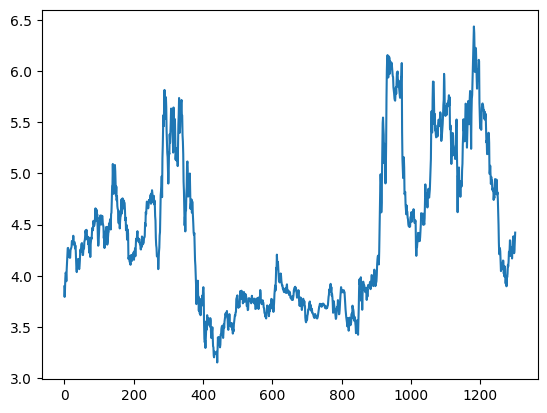

In [16]:
plt.plot(nu_arr)

    FITTED PARAMS VS SIMULATED

In [272]:
start = 1200
test_slice = log_returns_usd_scaled[start:start+365]

params, nu = student_simulation(test_slice, horizon=1)
print(params, nu)
# params.mean = np.array([params.mean])
# print(params, nu)
# print(params.mean)

SimParams(volatility=array([0.96601291]), mean=array([0.01017843])) 5.4483437597516


In [315]:
def testing_simulator(
    params: SimParams,
    T: int, 
    nu: float, 
    dist = 't',
    granularity: int = 1000,
):
    '''Simulates returns driven by the Student innovation. Allows for dynamic mean. 
    Returns a batch of simulated data. The simulated data is logged.  Works with the log returns best'''
    if params.volatility.shape[0] != params.mean.shape[0]:
        raise ValueError('params.volatility.shape[0] has to be equal to params.mean.shape[0]')

    if T < params.volatility.shape[0]: 
        raise ValueError('Quantity of forecasted volatility can not exceed number of days to simulte')
    
    elif T > params.volatility.shape[0]:
        print('Number of simulated days exceed number of forecasted volality points. Simulation will assume constant long-term volatility.')

    def simulate(n_paths: int, seed = None):
        if seed is not None:
            rng = np.random.default_rng(seed=seed)
        else:
            rng = np.random.default_rng()

        time_grid = T * granularity
        dt = 1 / granularity
        Z = stats.t.rvs(df=nu, size=(n_paths, time_grid)) #the innovation random variabled
        if nu > 2.0: 
            stoch_comp = Z * np.sqrt(nu-2) / np.sqrt(nu) #scaled to have unit variance 
        else: 
            raise ValueError('Can not model the price process as the innovation variable has non-finite variance')

        #iterating through available volatility points 
        d_log_S = np.zeros(shape=(n_paths, time_grid))
        for t in range(params.volatility.shape[0]):
            _t = t * granularity
            d_log_S[:, _t:_t+granularity] = (
                params.mean[t] * dt + 
                params.volatility[t] * stoch_comp[:, _t:] * np.sqrt(dt)
            )
        _T = params.volatility.shape[0] * granularity
        d_log_S[:, _T:] = ((params.mean[-1] * dt) +
                    + params.volatility[-1] * stoch_comp[:, _T:] * np.sqrt(dt))

        cum_log_returns = np.cumsum(d_log_S, axis=-1)
        return cum_log_returns
    
    return simulate

In [325]:
simulator = testing_simulator(params=params, T=1, nu=nu, granularity=1)
cum_returns = simulator(n_paths=50_000)
print(np.std(cum_returns))

0.9533947815880706
